In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

# Part A: Shepp-Logan Phantom and Radon Transform
This notebook generates a Shepp-Logan phantom and computes its Radon transform (sinogram) using Python.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import radon, rescale
import matplotlib.cm as cm


In [ ]:
image = shepp_logan_phantom()
image = rescale(image, scale=0.4, mode='reflect', channel_axis=None)

theta_dense = np.linspace(0., 180., max(image.shape), endpoint=False)
sinogram_dense = radon(image, theta=theta_dense, circle=True)

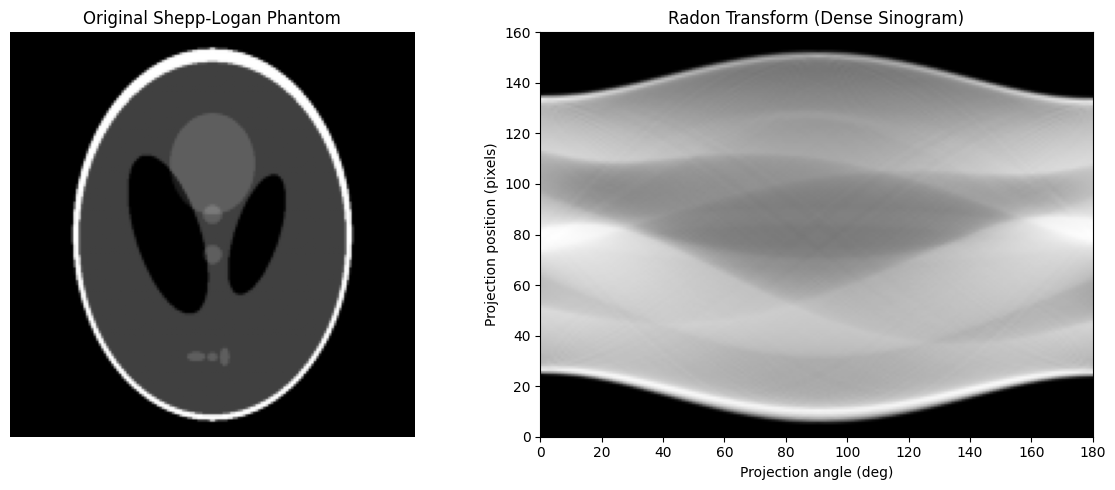

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].set_title("Original Shepp-Logan Phantom")
axes[0].imshow(image, cmap=cm.Greys_r)
axes[0].axis("off")

axes[1].set_title("Radon Transform (Dense Sinogram)")
axes[1].imshow(sinogram_dense, cmap=cm.Greys_r,
               extent=(0, 180, 0, sinogram_dense.shape[0]), aspect='auto')
axes[1].set_xlabel("Projection angle (deg)")
axes[1].set_ylabel("Projection position (pixels)")
plt.tight_layout()
plt.show()

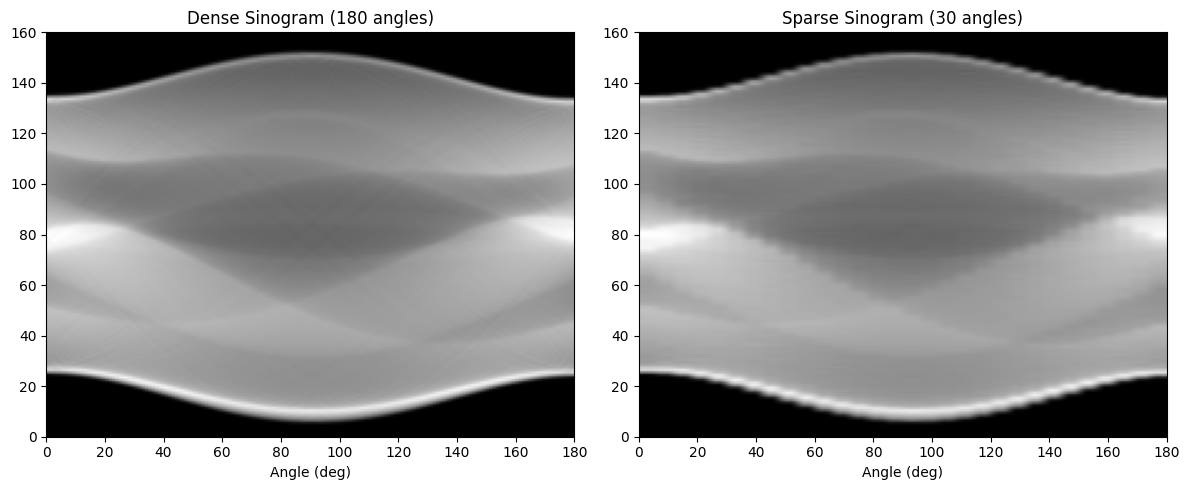

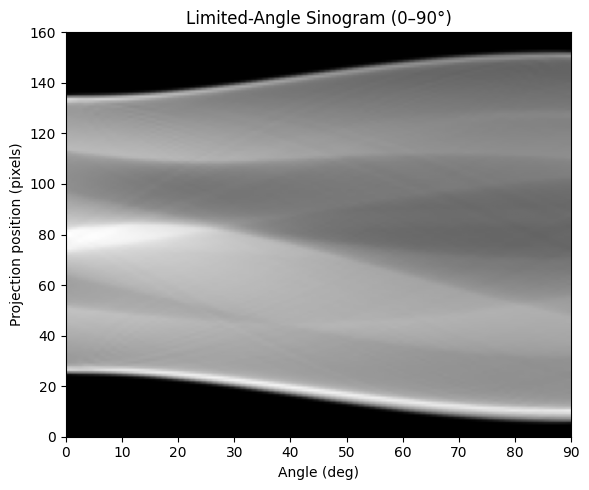

In [ ]:
theta_sparse = np.linspace(0., 180., 30, endpoint=False)
sinogram_sparse = radon(image, theta=theta_sparse, circle=True)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].set_title("Dense Sinogram (180 angles)")
axs[0].imshow(sinogram_dense, cmap='gray',
              extent=(0, 180, 0, sinogram_dense.shape[0]), aspect='auto')
axs[0].set_xlabel("Angle (deg)")

axs[1].set_title("Sparse Sinogram (30 angles)")
axs[1].imshow(sinogram_sparse, cmap='gray',
              extent=(0, 180, 0, sinogram_sparse.shape[0]), aspect='auto')
axs[1].set_xlabel("Angle (deg)")
plt.tight_layout()
plt.show()
theta_limited = np.linspace(0., 90., 90, endpoint=True)
sinogram_limited = radon(image, theta=theta_limited, circle=True)

plt.figure(figsize=(6, 5))
plt.title("Limited-Angle Sinogram (0–90°)")
plt.imshow(sinogram_limited, cmap='gray',
           extent=(0, 90, 0, sinogram_limited.shape[0]), aspect='auto')
plt.xlabel("Angle (deg)")
plt.ylabel("Projection position (pixels)")
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

angles_to_plot = [0, 45, 90, 135]
angle_indices = [int(a / 180 * len(theta)) for a in angles_to_plot]

plt.figure(figsize=(10, 6))
for i, idx in enumerate(angle_indices):
    plt.plot(sinogram[:, idx], label=f"{angles_to_plot[i]}°")

plt.title("Projections (1D Line Integrals) at Selected Angles")
plt.xlabel("Detector Position (pixels)")
plt.ylabel("Summed Intensity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'theta' is not defined

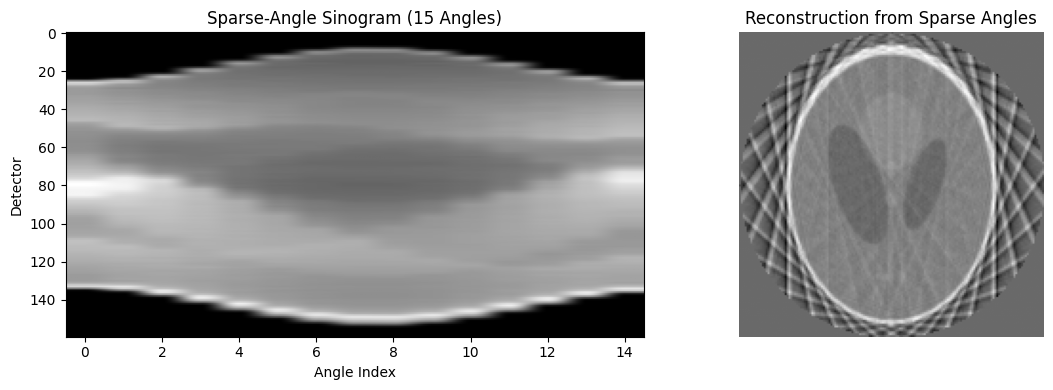

In [ ]:
from skimage.transform import iradon

theta_sparse = np.linspace(0., 180., 15, endpoint=False)
sinogram_sparse = radon(image, theta=theta_sparse, circle=True)
reconstruction_sparse = iradon(sinogram_sparse, theta=theta_sparse, circle=True)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.title("Sparse-Angle Sinogram (15 Angles)")
plt.imshow(sinogram_sparse, cmap='gray', aspect='auto')
plt.xlabel("Angle Index")
plt.ylabel("Detector")

plt.subplot(1, 2, 2)
plt.title("Reconstruction from Sparse Angles")
plt.imshow(reconstruction_sparse, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()


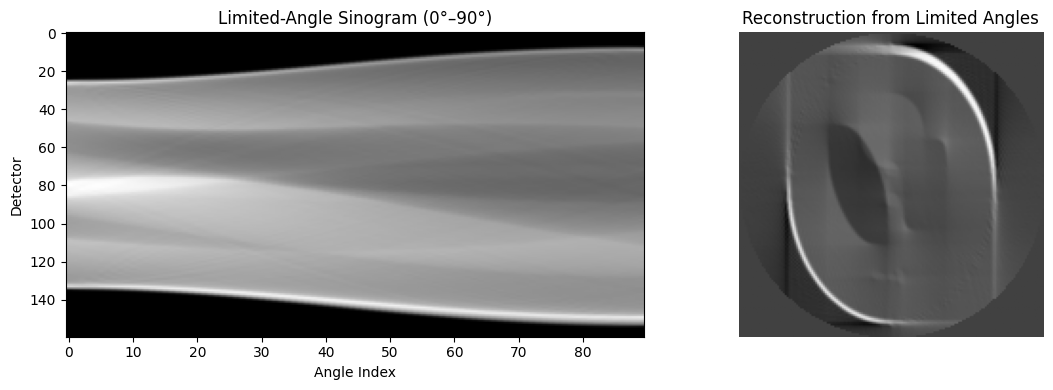

In [ ]:
theta_limited = np.linspace(0., 90., 90, endpoint=True)
sinogram_limited = radon(image, theta=theta_limited, circle=True)
reconstruction_limited = iradon(sinogram_limited, theta=theta_limited, circle=True)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.title("Limited-Angle Sinogram (0°–90°)")
plt.imshow(sinogram_limited, cmap='gray', aspect='auto')
plt.xlabel("Angle Index")
plt.ylabel("Detector")

plt.subplot(1, 2, 2)
plt.title("Reconstruction from Limited Angles")
plt.imshow(reconstruction_limited, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import radon, rescale
import matplotlib.animation as animation
from IPython.display import HTML
import matplotlib as mpl
mpl.rcParams['animation.embed_limit'] = 100


image = shepp_logan_phantom()
image = rescale(image, scale=0.4, mode='reflect', channel_axis=None)

theta = np.linspace(0., 180., 180, endpoint=False)
sinogram = radon(image, theta=theta, circle=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
im1 = ax1.imshow(image, cmap='gray')
ax1.set_title("Phantom with Projection Line")
line, = ax1.plot([], [], 'r-', lw=1)

im2 = ax2.imshow(np.zeros_like(sinogram), cmap='gray',
                 extent=(0, 180, 0, sinogram.shape[0]), aspect='auto',
                 vmin=sinogram.min(), vmax=sinogram.max())
ax2.set_title("Building the Sinogram")
ax2.set_xlabel("Projection Angle (deg)")
ax2.set_ylabel("Detector Position (pixels)")

sinogram_partial = np.zeros_like(sinogram)

def init():
    im2.set_data(sinogram_partial)
    line.set_data([], [])
    return im1, im2, line

def update(i):
    angle = np.deg2rad(theta[i])
    x0, y0 = image.shape[1] // 2, image.shape[0] // 2
    length = max(image.shape) * 1.5
    dx = np.cos(angle)
    dy = np.sin(angle)
    x1 = x0 - dx * length
    y1 = y0 - dy * length
    x2 = x0 + dx * length
    y2 = y0 + dy * length
    line.set_data([x1, x2], [y1, y2])

    sinogram_partial[:, i] = sinogram[:, i]
    im2.set_data(sinogram_partial)
    return im1, im2, line

ani = animation.FuncAnimation(fig, update, frames=len(theta), init_func=init,
                              blit=True, interval=60, repeat=False)

plt.close(fig)
HTML(ani.to_jshtml())


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import radon, rescale
import matplotlib as mpl
mpl.use('Agg')

output_dir = "frames"
os.makedirs(output_dir, exist_ok=True)

image = shepp_logan_phantom()
image = rescale(image, 0.4, mode='reflect', channel_axis=None)

theta = np.linspace(0., 180., 180, endpoint=False)
sinogram = radon(image, theta=theta, circle=True)
sinogram_partial = np.zeros_like(sinogram)

for i in range(len(theta)):
    sinogram_partial[:, i] = sinogram[:, i]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    ax1.imshow(image, cmap='gray')
    ax1.set_title(f"Phantom with Projection Line ({int(theta[i])}°)")

    x0, y0 = image.shape[1] // 2, image.shape[0] // 2
    length = max(image.shape) * 1.5
    angle = np.deg2rad(theta[i])
    dx = np.cos(angle)
    dy = np.sin(angle)
    x1 = x0 - dx * length
    y1 = y0 - dy * length
    x2 = x0 + dx * length
    y2 = y0 + dy * length
    ax1.plot([x1, x2], [y1, y2], 'r-', lw=1)

    ax2.imshow(sinogram_partial, cmap='gray', extent=(0, 180, 0, sinogram.shape[0]), aspect='auto')
    ax2.set_title("Accumulated Sinogram")
    ax2.set_xlabel("Angle (deg)")
    ax2.set_ylabel("Detector")

    plt.tight_layout()
    plt.savefig(f"{output_dir}/frame_{i:03d}.png")
    plt.close(fig)


In [ ]:
!zip -r frames.zip frames
from google.colab import files
files.download("frames.zip")


  adding: frames/ (stored 0%)
  adding: frames/frame_123.png (deflated 5%)
  adding: frames/frame_140.png (deflated 5%)
  adding: frames/frame_063.png (deflated 7%)
  adding: frames/frame_116.png (deflated 5%)
  adding: frames/frame_110.png (deflated 6%)
  adding: frames/frame_137.png (deflated 5%)
  adding: frames/frame_020.png (deflated 10%)
  adding: frames/frame_080.png (deflated 7%)
  adding: frames/frame_152.png (deflated 5%)
  adding: frames/frame_129.png (deflated 5%)
  adding: frames/frame_038.png (deflated 8%)
  adding: frames/frame_037.png (deflated 8%)
  adding: frames/frame_011.png (deflated 11%)
  adding: frames/frame_124.png (deflated 5%)
  adding: frames/frame_045.png (deflated 8%)
  adding: frames/frame_034.png (deflated 9%)
  adding: frames/frame_088.png (deflated 7%)
  adding: frames/frame_056.png (deflated 7%)
  adding: frames/frame_178.png (deflated 6%)
  adding: frames/frame_092.png (deflated 6%)
  adding: frames/frame_101.png (deflated 6%)
  adding: frames/frame_

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Part B: Filtered Back Projection

In [ ]:
from skimage.transform import iradon

reconstruction_ramlak = iradon(sinogram, theta=theta, filter_name='ramp', circle=True)

plt.figure(figsize=(6, 6))
plt.title("Reconstruction with Ram-Lak Filter")
plt.imshow(reconstruction_ramlak, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()


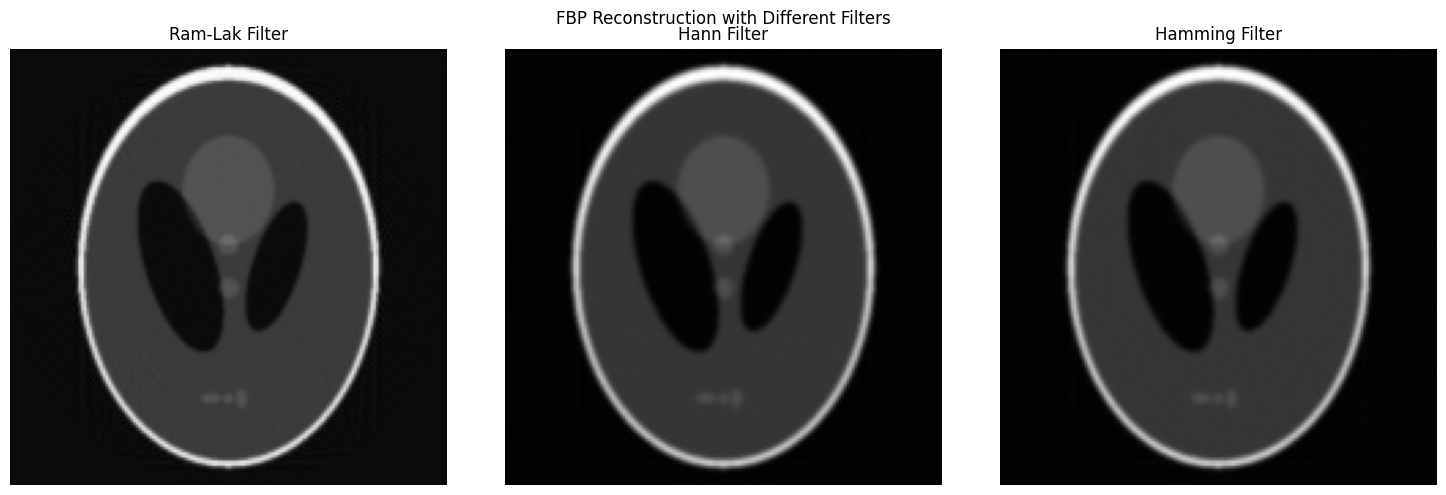

In [ ]:
reconstruction_hann = iradon(sinogram, theta=theta, filter_name='hann', circle=True)
reconstruction_hamming = iradon(sinogram, theta=theta, filter_name='hamming', circle=True)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(reconstruction_ramlak, cmap='gray')
axs[0].set_title("Ram-Lak Filter")
axs[0].axis('off')

axs[1].imshow(reconstruction_hann, cmap='gray')
axs[1].set_title("Hann Filter")
axs[1].axis('off')

axs[2].imshow(reconstruction_hamming, cmap='gray')
axs[2].set_title("Hamming Filter")
axs[2].axis('off')

plt.suptitle("FBP Reconstruction with Different Filters")
plt.tight_layout()
plt.show()


In [ ]:
theta_sparse = np.linspace(0., 180., 30, endpoint=False)
sinogram_sparse = radon(image, theta=theta_sparse, circle=True)
reconstruction_sparse = iradon(sinogram_sparse, theta=theta_sparse, filter_name='ramp', circle=True)

plt.figure(figsize=(6, 6))
plt.title("FBP with Sparse Angles (30)")
plt.imshow(reconstruction_sparse, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()


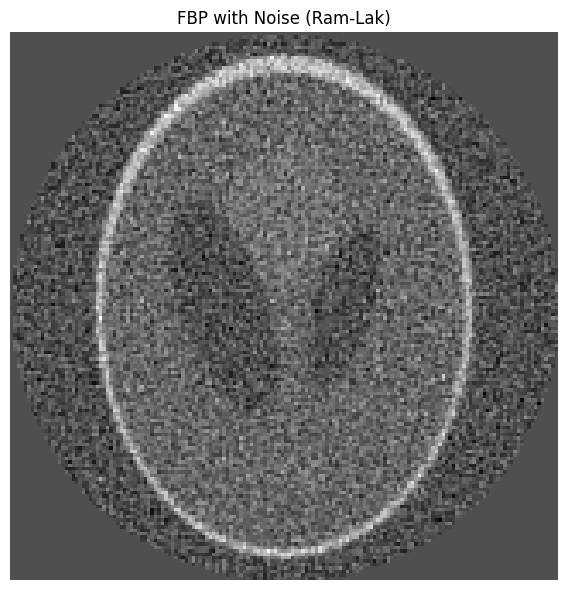

In [ ]:
noise_std = 0.1 * np.max(sinogram)
sinogram_noisy = sinogram + np.random.normal(0, noise_std, sinogram.shape)

reconstruction_noisy = iradon(sinogram_noisy, theta=theta, filter_name='ramp', circle=True)

plt.figure(figsize=(6, 6))
plt.title("FBP with Noise (Ram-Lak)")
plt.imshow(reconstruction_noisy, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
from skimage.metrics import mean_squared_error, structural_similarity as ssim
import pandas as pd

mse_ramlak = mean_squared_error(image, reconstruction_ramlak)
mse_hann = mean_squared_error(image, reconstruction_hann)
mse_hamming = mean_squared_error(image, reconstruction_hamming)
mse_noisy = mean_squared_error(image, reconstruction_noisy)
mse_sparse = mean_squared_error(image, reconstruction_sparse)


ssim_ramlak = ssim(image, reconstruction_ramlak, data_range=1.0)
ssim_hann = ssim(image, reconstruction_hann, data_range=1.0)
ssim_hamming = ssim(image, reconstruction_hamming, data_range=1.0)
ssim_noisy = ssim(image, reconstruction_noisy, data_range=1.0)
ssim_sparse = ssim(image, reconstruction_sparse, data_range=1.0)


print("MSE (Ram-Lak):", mse_ramlak)
print("MSE (Hann):   ", mse_hann)
print("MSE (Hamming):", mse_hamming)
print("MSE (Noisy Ram-Lak):", mse_noisy)
print("MSE (Sparse Ram-Lak):", mse_sparse)


print("SSIM (Ram-Lak):", ssim_ramlak)
print("SSIM (Hann):   ", ssim_hann)
print("SSIM (Hamming):", ssim_hamming)
print("SSIM (Noisy Ram-Lak):", ssim_noisy)
print("SSIM (Sparse Ram-Lak):", ssim_sparse)


results_data = {
    "Filter": ["Ram-Lak", "Hann", "Hamming", "Noisy Ram-Lak", "Sparse Ram-Lak"],
    "MSE": [mse_ramlak, mse_hann, mse_hamming, mse_noisy, mse_sparse],
    "SSIM": [ssim_ramlak, ssim_hann, ssim_hamming, ssim_noisy, ssim_sparse]
}


df_results = pd.DataFrame(results_data)

print("\nFBP Filter Performance Comparison:")
print(df_results.to_string(index=False))


NameError: name 'reconstruction_hann' is not defined

# Part C MLE: Statistical Reconstruction

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import radon, iradon
from skimage.transform import rescale

image = shepp_logan_phantom()
image = rescale(image, 0.4, channel_axis=None)

theta = np.linspace(0., 180., 3, endpoint=False)
sinogram = radon(image, theta=theta, circle=True)

sinogram_noisy = np.random.poisson(sinogram * 20) / 20

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Phantom")
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Noisy Sinogram")
plt.imshow(sinogram_noisy, cmap='gray', aspect='auto')
plt.xlabel("Angle Index")
plt.ylabel("Detector Position")
plt.tight_layout()
plt.show()


In [ ]:
def A_forward(x_img, theta):
    return radon(x_img, theta=theta, circle=True)

def A_transpose(y_proj, theta, output_shape):
    return iradon(y_proj, theta=theta, filter_name=None, circle=True, output_size=output_shape[0])

def em_mle(sinogram, theta, n_iter=2000):
    x_est = iradon(sinogram, theta=theta, filter_name='ramp', circle=True)
    x_est = np.clip(x_est, 1e-3, None)
    ones_proj = A_forward(np.ones_like(x_est), theta)

    for i in range(n_iter):
        Ax = A_forward(x_est, theta)
        ratio = sinogram / (Ax + 1e-8)
        backproj = A_transpose(ratio, theta, x_est.shape)
        backproj_norm = A_transpose(ones_proj, theta, x_est.shape)
        x_est *= backproj / (backproj_norm + 1e-8)

    return x_est


In [ ]:
reconstruction_em = em_mle(sinogram_noisy, theta, n_iter=2000)

plt.figure(figsize=(6, 6))
plt.title("MLE Reconstruction (EM Algorithm)")
plt.imshow(reconstruction_em, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/skimage/transform/radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(


# Part C MAP: Cont


In [ ]:
from scipy.ndimage import laplace

def compute_laplacian_prior(x):
    return laplace(x)

def em_map(sinogram, theta, n_iter=200, lam=0.1):
    x_est = iradon(sinogram, theta=theta, filter_name='ramp', circle=True)
    x_est = np.clip(x_est, 1e-3, None)

    ones_proj = A_forward(np.ones_like(x_est), theta)

    for i in range(n_iter):
        Ax = A_forward(x_est, theta)
        ratio = sinogram / (Ax + 1e-8)
        backproj = A_transpose(ratio, theta, x_est.shape)
        backproj_norm = A_transpose(ones_proj, theta, x_est.shape)

        lap = compute_laplacian_prior(x_est)
        x_est *= backproj / (backproj_norm + lam * lap + 1e-8)

    return x_est


In [ ]:
reconstruction_map = em_map(sinogram_noisy, theta, n_iter=200, lam=0.01)

plt.figure(figsize=(6, 6))
plt.title("MAP Reconstruction (EM + Smoothness Prior)")
plt.imshow(reconstruction_map / reconstruction_map.max(), cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
from skimage.restoration import denoise_tv_chambolle

denoised_map = denoise_tv_chambolle(reconstruction_map, weight=0.3)

plt.figure(figsize=(6, 6))
plt.title("MAP + TV Denoising")
plt.imshow(denoised_map, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()


# Part C SART

In [ ]:
from skimage.transform import iradon_sart

recon_sart_noisy = iradon_sart(sinogram_noisy, theta=theta)

for _ in range(4):
    recon_sart_noisy = iradon_sart(sinogram_noisy, theta=theta, image=recon_sart_noisy)
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.title("SART Reconstruction from Noisy Sinogram")
plt.imshow(recon_sart_noisy, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()


# Part C: MSE + SSIM

In [ ]:
from skimage.metrics import mean_squared_error, structural_similarity as ssim
import pandas as pd
import numpy as np

def normalize(img):
    return img / np.max(img) if np.max(img) > 0 else img

image_norm = normalize(image)

recon_em_norm = normalize(reconstruction_em)
recon_map_norm = normalize(reconstruction_map)
denoised_map_norm = normalize(denoised_map)
recon_sart_noisy_norm = normalize(recon_sart_noisy)

methods = ["MLE (EM)", "MAP", "MAP + TV", "SART (Noisy)"]
reconstructions = [recon_em_norm, recon_map_norm, denoised_map_norm, recon_sart_noisy_norm]

mse_list = []
ssim_list = []

for recon in reconstructions:
    mse = mean_squared_error(image_norm, recon)
    ssim_val = ssim(image_norm, recon, data_range=1.0)
    mse_list.append(mse)
    ssim_list.append(ssim_val)

metrics_df = pd.DataFrame({
    "Method": methods,
    "MSE": mse_list,
    "SSIM": ssim_list
})

print("\n📊 Reconstruction Quality Metrics:")
print(metrics_df.to_string(index=False))



📊 Reconstruction Quality Metrics:
      Method      MSE     SSIM
    MLE (EM) 0.045801 0.440194
         MAP 0.045805 0.440203
    MAP + TV 0.067912 0.275273
SART (Noisy) 0.026919 0.475136
